In [1]:
!pip install pandas pyarrow matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_parquet(
    "final_analytics_data.parquet"
)

print("Shape:", df.shape)

display(df.head())

Shape: (8619, 19)


,timestamp,consumption_mw,wind_onshore_mw,solar_mw,gas_mw,coal_mw,price_eur_mwh,wind_offshore_mw,biomass_mw,hydro_mw,lignite_mw,other_renewables_mw,renewable_generation_mw,renewable_share_pct,date,hour,day_of_week,month,month_name
0,2025-08-31 22:00:00,39947.01,12740.28,7.38,4596.50,1664.75,84.08,4774.56,3552.27,1632.67,7031.50,100.30,22807.46,57.094286,2025-08-31,22,Sunday,8,August
1,2025-08-31 23:00:00,39017.77,13182.18,7.49,4538.50,1616.25,81.43,3709.63,3478.34,1622.75,6791.75,100.94,22101.33,56.644267,2025-08-31,23,Sunday,8,August
2,2025-09-01 00:00:00,37956.16,12593.54,8.50,4705.75,1627.25,80.97,2375.40,3455.61,1632.35,6920.00,101.41,20166.81,53.131850,2025-09-01,0,Monday,9,September
3,2025-09-01 01:00:00,37650.69,12599.03,7.91,4701.50,1632.00,80.03,1490.00,3467.22,1545.54,7185.50,101.57,19211.27,51.025014,2025-09-01,1,Monday,9,September
4,2025-09-01 02:00:00,38324.95,12846.25,7.47,4962.75,1725.00,81.37,765.38,3537.74,1556.14,7308.50,101.49,18814.47,49.091962,2025-09-01,2,Monday,9,September


In [3]:
print(df.columns.tolist())

['timestamp', 'consumption_mw', 'wind_onshore_mw', 'solar_mw', 'gas_mw', 'coal_mw', 'price_eur_mwh', 'wind_offshore_mw', 'biomass_mw', 'hydro_mw', 'lignite_mw', 'other_renewables_mw', 'renewable_generation_mw', 'renewable_share_pct', 'date', 'hour', 'day_of_week', 'month', 'month_name']


Chart 1 — Electricity price

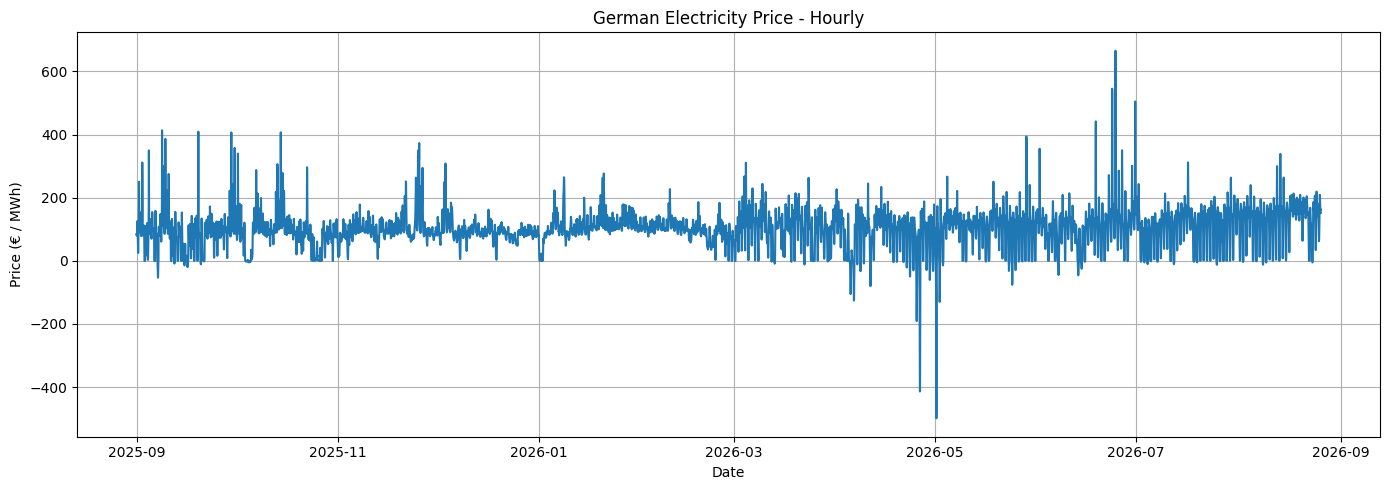

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["price_eur_mwh"]
)

plt.title("German Electricity Price - Hourly")
plt.xlabel("Date")
plt.ylabel("Price (€ / MWh)")

plt.grid(True)
plt.tight_layout()
plt.show()

Chart 2 — Renewable generation

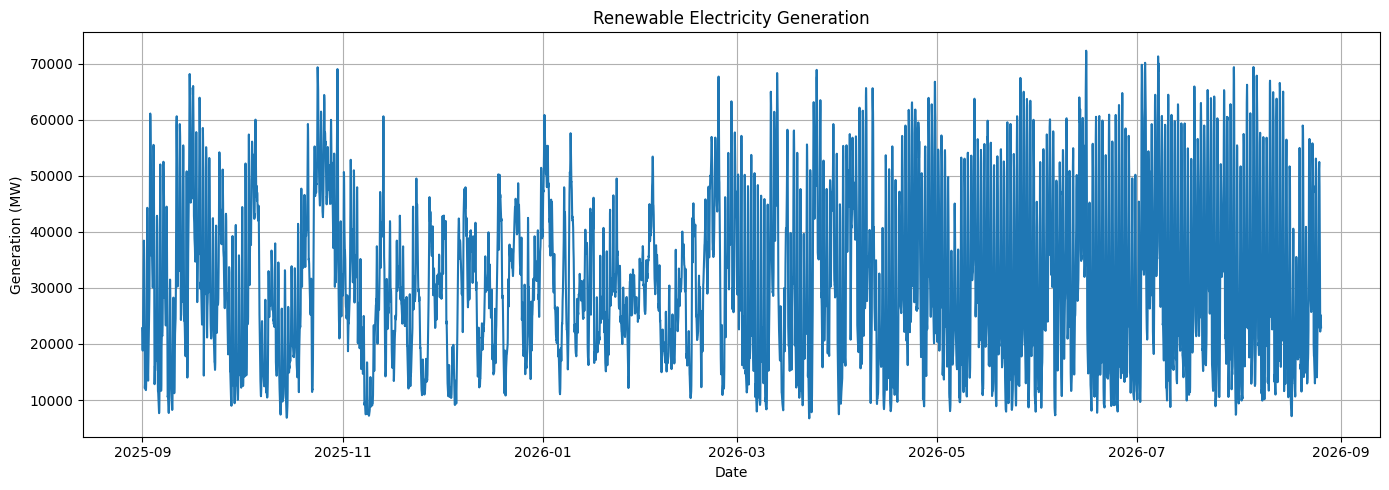

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["renewable_generation_mw"]
)

plt.title("Renewable Electricity Generation")
plt.xlabel("Date")
plt.ylabel("Generation (MW)")

plt.grid(True)
plt.tight_layout()
plt.show()

Renewable share

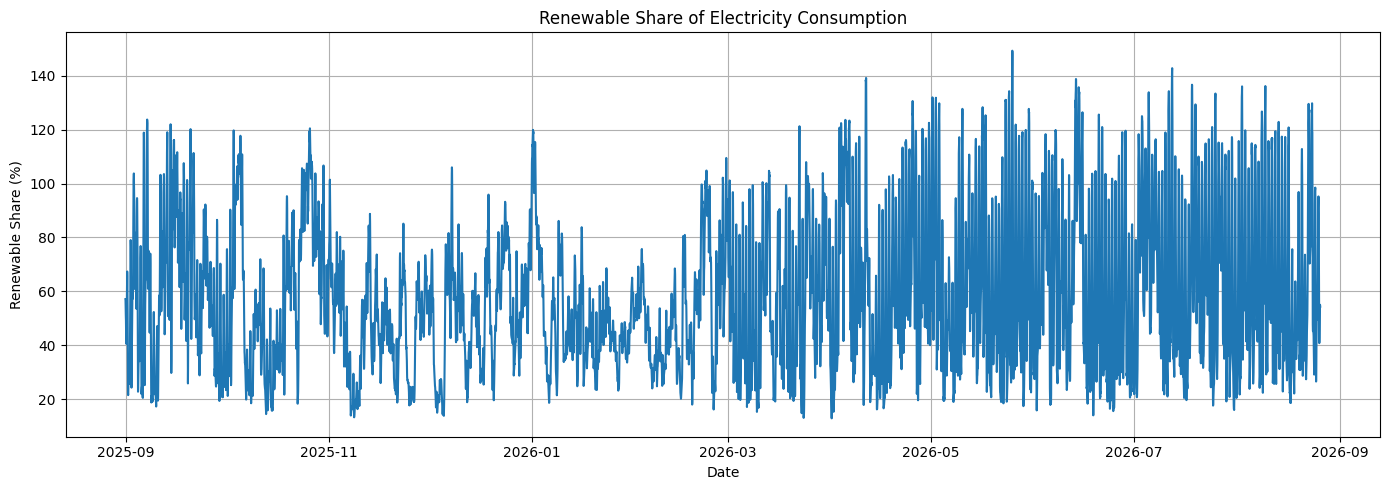

In [6]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["renewable_share_pct"]
)

plt.title("Renewable Share of Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Renewable Share (%)")

plt.grid(True)
plt.tight_layout()
plt.show()

# Duck curve

Chart 4 — Duck curve

Net demand = Consumption − Solar

Create net demand

In [7]:
df["net_demand_mw"] = (
    df["consumption_mw"]
    - df["solar_mw"]
)

print("Net demand calculated!")

display(
    df[
        [
            "timestamp",
            "consumption_mw",
            "solar_mw",
            "net_demand_mw"
        ]
    ].head()
)

Net demand calculated!


,timestamp,consumption_mw,solar_mw,net_demand_mw
0,2025-08-31 22:00:00,39947.01,7.38,39939.63
1,2025-08-31 23:00:00,39017.77,7.49,39010.28
2,2025-09-01 00:00:00,37956.16,8.50,37947.66
3,2025-09-01 01:00:00,37650.69,7.91,37642.78
4,2025-09-01 02:00:00,38324.95,7.47,38317.48


Average hourly duck curve

In [8]:
hourly_profile = (
    df.groupby("hour")
    .agg(
        average_demand=("consumption_mw", "mean"),
        average_solar=("solar_mw", "mean"),
        average_net_demand=("net_demand_mw", "mean")
    )
    .reset_index()
)

display(hourly_profile)

,hour,average_demand,average_solar,average_net_demand
0,0,44159.601194,7.991000,44151.610194
1,1,43810.861978,7.895376,43802.966602
2,2,44283.645599,8.532730,44275.112869
3,3,46038.764596,110.794986,45927.969610
4,4,49914.026518,1010.869164,48903.157354
5,5,54303.505543,3668.134373,50635.371170
6,6,57599.412646,8612.370529,48987.042117
7,7,59208.008496,14918.103064,44289.905432
8,8,59690.458050,21059.424958,38631.033092
9,9,59798.236992,25638.337493,34159.899499


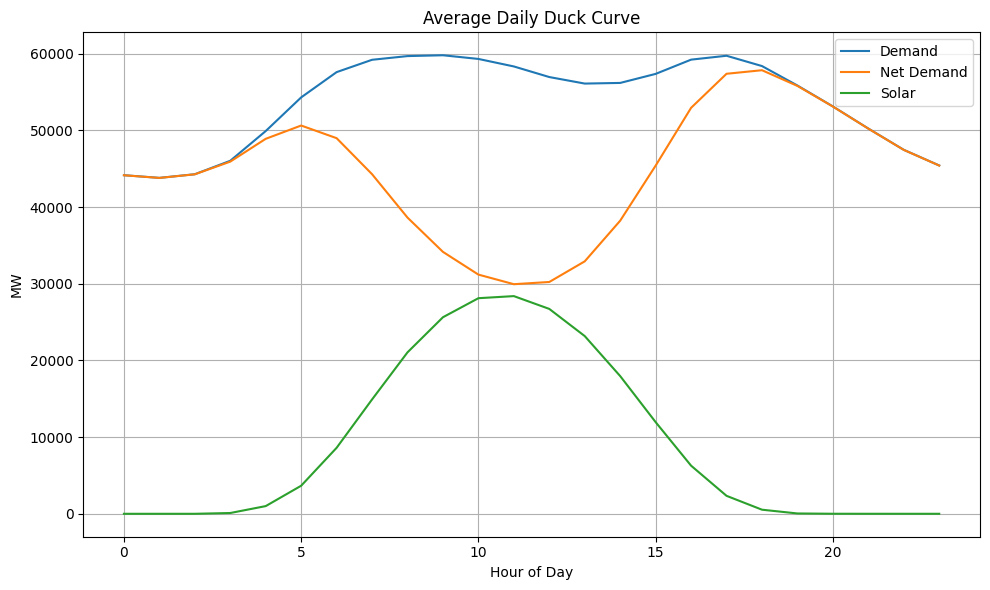

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_profile["hour"],
    hourly_profile["average_demand"],
    label="Demand"
)

plt.plot(
    hourly_profile["hour"],
    hourly_profile["average_net_demand"],
    label="Net Demand"
)

plt.plot(
    hourly_profile["hour"],
    hourly_profile["average_solar"],
    label="Solar"
)

plt.title("Average Daily Duck Curve")
plt.xlabel("Hour of Day")
plt.ylabel("MW")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Chart 5 — Hourly heatmap

In [10]:
df["day"] = df["timestamp"].dt.date

price_heatmap = df.pivot_table(
    index="day",
    columns="hour",
    values="price_eur_mwh",
    aggfunc="mean"
)

print("Heatmap shape:", price_heatmap.shape)

display(price_heatmap.head())

Heatmap shape: (361, 24)


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day,,,,,,,,,,,,,,,,,,,,,
2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.08,81.43
2025-09-01,80.97,80.03,81.37,92.58,120.43,125.67,116.10,98.19,82.00,69.40,...,84.67,109.70,155.32,250.65,210.56,125.20,112.40,100.53,95.01,90.11
2025-09-02,90.84,92.50,94.80,106.85,134.39,153.67,147.48,121.05,102.14,84.66,...,95.00,108.97,173.16,311.51,263.79,140.92,110.47,91.21,97.25,90.74
2025-09-03,85.95,81.72,81.23,86.97,103.20,112.34,109.13,85.30,29.04,0.03,...,3.89,63.46,102.35,110.92,104.00,94.17,80.68,54.25,21.65,17.70
2025-09-04,17.87,30.02,59.92,83.89,107.87,120.00,108.09,77.81,41.45,5.79,...,90.05,109.13,191.80,350.00,218.82,124.93,112.14,101.30,95.25,86.10


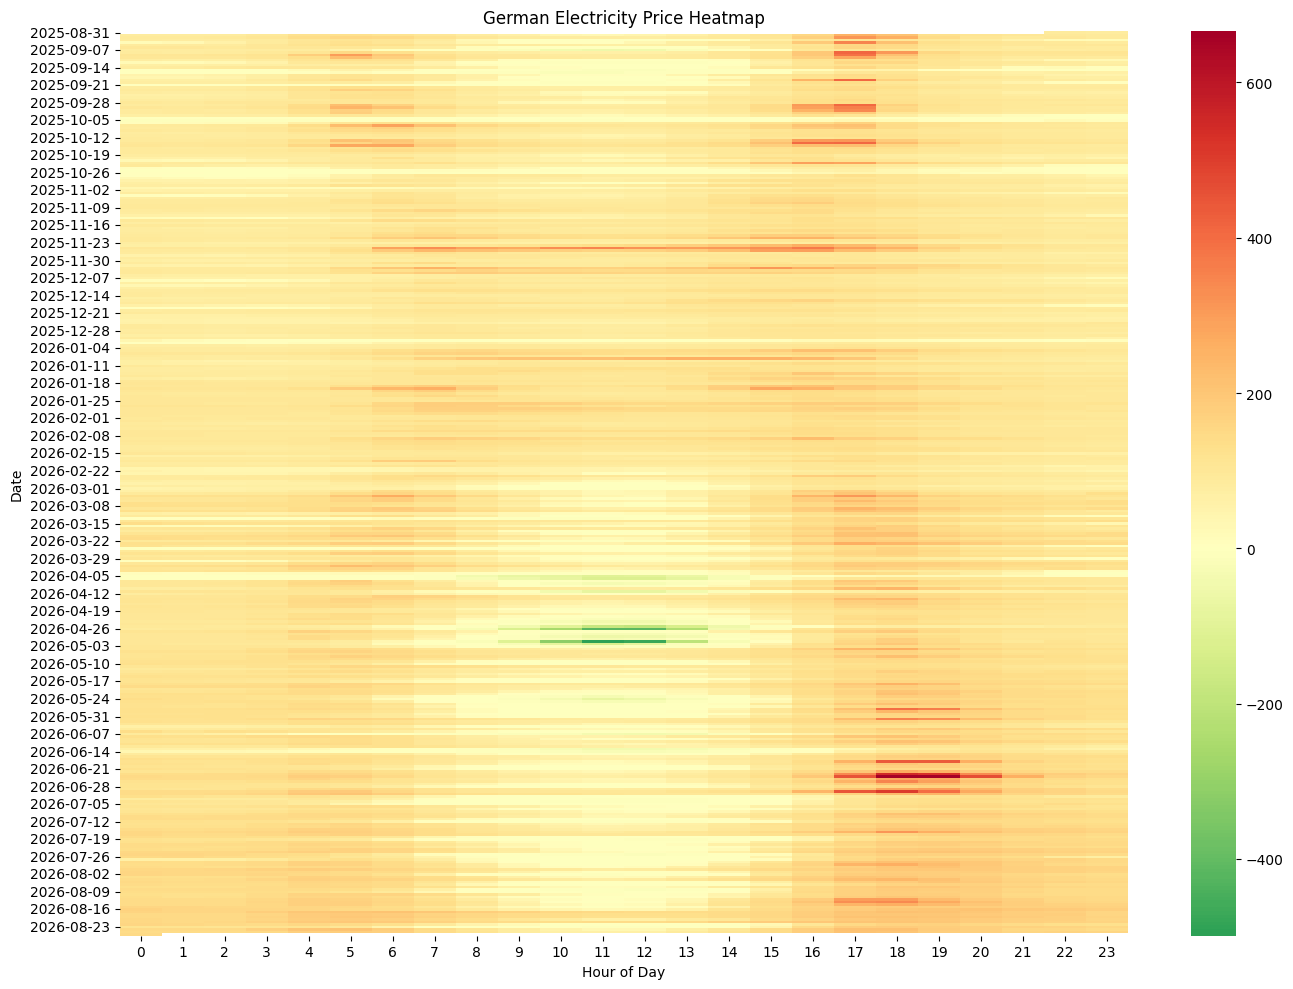

In [11]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    price_heatmap,
    cmap="RdYlGn_r",
    center=0
)

plt.title("German Electricity Price Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Date")

plt.tight_layout()
plt.show()

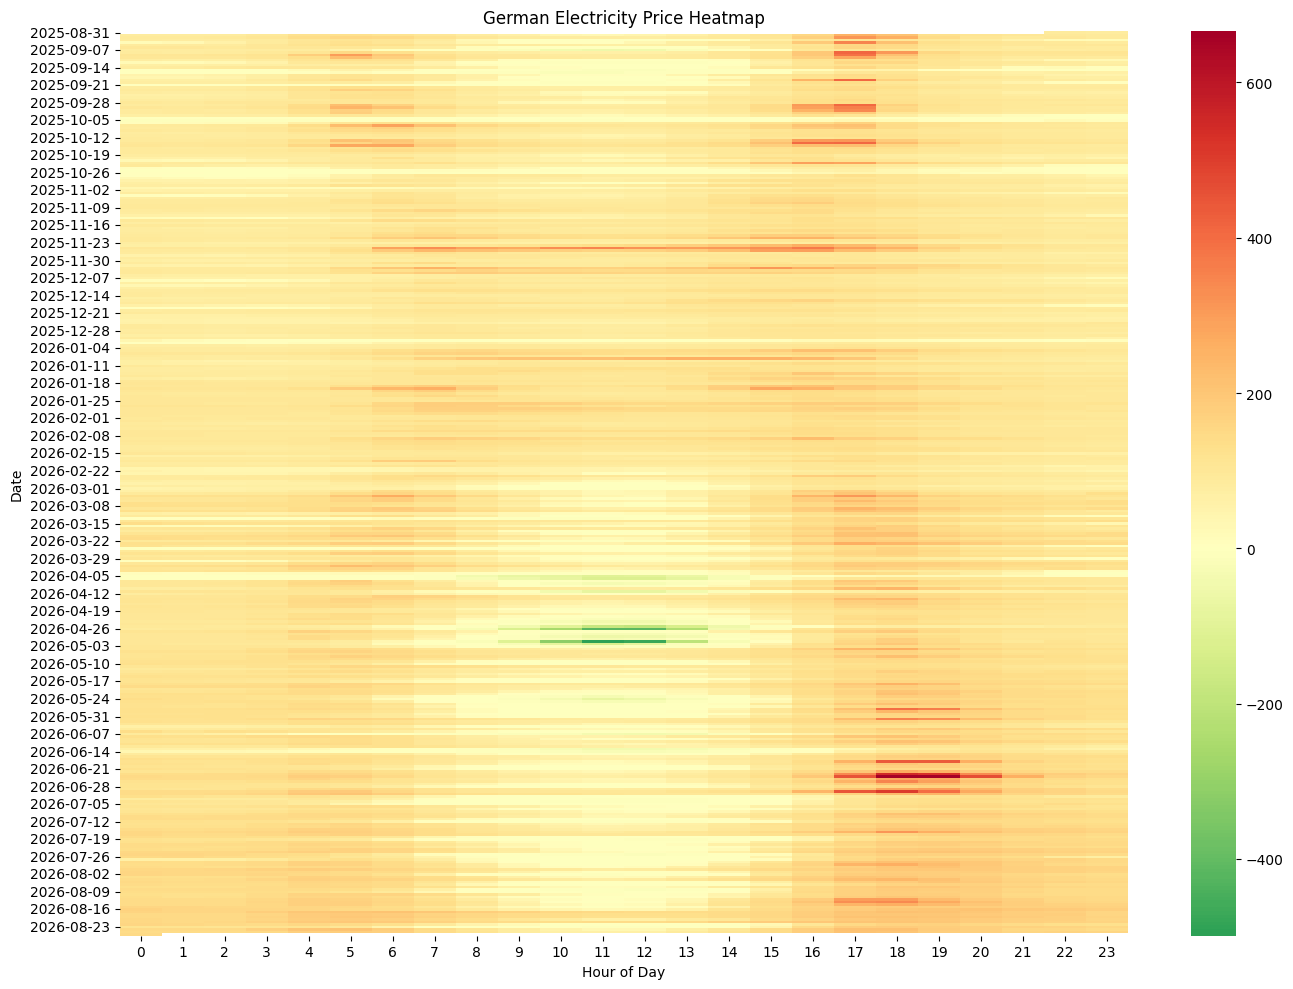

In [12]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    price_heatmap,
    cmap="RdYlGn_r",
    center=0
)

plt.title("German Electricity Price Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Date")

plt.tight_layout()
plt.show()

Define energy groups

In [13]:
renewable_columns = [
    "wind_onshore_mw",
    "wind_offshore_mw",
    "solar_mw",
    "biomass_mw",
    "hydro_mw",
    "other_renewables_mw"
]

fossil_columns = [
    "gas_mw",
    "coal_mw",
    "lignite_mw"
]

df["renewable_mw"] = df[renewable_columns].sum(axis=1)

df["fossil_mw"] = df[fossil_columns].sum(axis=1)

df["listed_generation_mw"] = (
    df["renewable_mw"] +
    df["fossil_mw"]
)

df["renewable_generation_share_pct"] = (
    df["renewable_mw"] /
    df["listed_generation_mw"] *
    100
)

df["fossil_generation_share_pct"] = (
    df["fossil_mw"] /
    df["listed_generation_mw"] *
    100
)

print("Energy groups created!")

display(
    df[
        [
            "timestamp",
            "renewable_mw",
            "fossil_mw",
            "listed_generation_mw",
            "renewable_generation_share_pct"
        ]
    ].head()
)

Energy groups created!


,timestamp,renewable_mw,fossil_mw,listed_generation_mw,renewable_generation_share_pct
0,2025-08-31 22:00:00,22807.46,13292.75,36100.21,63.178192
1,2025-08-31 23:00:00,22101.33,12946.50,35047.83,63.060480
2,2025-09-01 00:00:00,20166.81,13253.00,33419.81,60.343880
3,2025-09-01 01:00:00,19211.27,13519.00,32730.27,58.695727
4,2025-09-01 02:00:00,18814.47,13996.25,32810.72,57.342448


Overall generation mix

In [14]:
average_renewable = df["renewable_mw"].mean()
average_fossil = df["fossil_mw"].mean()

total_average = (
    average_renewable +
    average_fossil
)

renewable_pct = (
    average_renewable /
    total_average *
    100
)

fossil_pct = (
    average_fossil /
    total_average *
    100
)

print("========== GENERATION MIX ==========")
print(f"Average renewable generation: {average_renewable:,.0f} MW")
print(f"Average fossil generation: {average_fossil:,.0f} MW")
print(f"Renewable share: {renewable_pct:.1f}%")
print(f"Fossil share: {fossil_pct:.1f}%")
print("====================================")

========== GENERATION MIX ==========
Average renewable generation: 31,241 MW
Average fossil generation: 18,019 MW
Renewable share: 63.4%
Fossil share: 36.6%


Which energy source matters most?

In [15]:
source_columns = {
    "Solar": "solar_mw",
    "Wind Onshore": "wind_onshore_mw",
    "Wind Offshore": "wind_offshore_mw",
    "Biomass": "biomass_mw",
    "Hydro": "hydro_mw",
    "Other Renewables": "other_renewables_mw",
    "Gas": "gas_mw",
    "Coal": "coal_mw",
    "Lignite": "lignite_mw"
}

source_average = {}

for source, column in source_columns.items():
    source_average[source] = df[column].mean()

source_table = (
    pd.DataFrame.from_dict(
        source_average,
        orient="index",
        columns=["average_mw"]
    )
    .sort_values("average_mw", ascending=False)
)

source_table["share_of_listed_generation_pct"] = (
    source_table["average_mw"] /
    source_table["average_mw"].sum() *
    100
)

display(source_table)

,average_mw,share_of_listed_generation_pct
Wind Onshore,12981.167256,26.352079
Solar,9190.435704,18.656804
Lignite,7473.527870,15.171440
Gas,7137.223835,14.488735
Biomass,4052.078138,8.225815
Coal,3408.391411,6.919116
Wind Offshore,3407.616509,6.917543
Hydro,1506.564810,3.058363
Other Renewables,103.498923,0.210105


# seasons

Create seasons

In [16]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


df["season"] = df["timestamp"].dt.month.apply(get_season)

print(
    df[
        ["timestamp", "season"]
    ].head(10)
)

            timestamp  season
0 2025-08-31 22:00:00  Summer
1 2025-08-31 23:00:00  Summer
2 2025-09-01 00:00:00  Autumn
3 2025-09-01 01:00:00  Autumn
4 2025-09-01 02:00:00  Autumn
5 2025-09-01 03:00:00  Autumn
6 2025-09-01 04:00:00  Autumn
7 2025-09-01 05:00:00  Autumn
8 2025-09-01 06:00:00  Autumn
9 2025-09-01 07:00:00  Autumn


Seasonal renewable vs fossil analysis

In [17]:
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

seasonal = (
    df.groupby("season")
    .agg(
        renewable_avg_mw=("renewable_mw", "mean"),
        fossil_avg_mw=("fossil_mw", "mean"),
        renewable_share_pct=(
            "renewable_generation_share_pct",
            "mean"
        ),
        solar_avg_mw=("solar_mw", "mean"),
        wind_onshore_avg_mw=(
            "wind_onshore_mw",
            "mean"
        ),
        wind_offshore_avg_mw=(
            "wind_offshore_mw",
            "mean"
        ),
        consumption_avg_mw=(
            "consumption_mw",
            "mean"
        ),
        price_avg_eur_mwh=(
            "price_eur_mwh",
            "mean"
        )
    )
    .reindex(season_order)
)

display(seasonal.round(2))

,renewable_avg_mw,fossil_avg_mw,renewable_share_pct,solar_avg_mw,wind_onshore_avg_mw,wind_offshore_avg_mw,consumption_avg_mw,price_avg_eur_mwh
season,,,,,,,,
Winter,30377.08,25202.03,53.94,2630.45,16972.93,5018.52,59923.50,100.14
Spring,31508.37,15531.68,63.23,13087.46,10170.34,2574.95,51201.58,91.98
Summer,32836.05,12626.64,67.38,15647.83,9388.60,2331.25,49968.79,113.87
Autumn,30316.94,18533.61,60.14,5627.02,15275.09,3674.94,54206.74,89.87


Which season is strongest for renewables?

In [18]:
highest_renewable_season = (
    seasonal["renewable_avg_mw"].idxmax()
)

highest_share_season = (
    seasonal["renewable_share_pct"].idxmax()
)

highest_solar_season = (
    seasonal["solar_avg_mw"].idxmax()
)

highest_wind_season = (
    (
        seasonal["wind_onshore_avg_mw"]
        + seasonal["wind_offshore_avg_mw"]
    )
    .idxmax()
)

print(
    "Highest renewable generation:",
    highest_renewable_season
)

print(
    "Highest renewable share:",
    highest_share_season
)

print(
    "Highest solar generation:",
    highest_solar_season
)

print(
    "Highest combined wind generation:",
    highest_wind_season
)

Highest renewable generation: Summer
Highest renewable share: Summer
Highest solar generation: Summer
Highest combined wind generation: Winter


Seasonal price relationship

In [20]:
# Create negative-price flag
df["negative_price"] = df["price_eur_mwh"] < 0

# Seasonal price analysis
seasonal_price = (
    df.groupby("season")
    .agg(
        average_price=("price_eur_mwh", "mean"),
        negative_price_hours=("negative_price", "sum"),
        renewable_generation=("renewable_mw", "mean"),
        renewable_share=(
            "renewable_generation_share_pct",
            "mean"
        )
    )
    .reindex(season_order)
)

display(seasonal_price.round(2))

,average_price,negative_price_hours,renewable_generation,renewable_share
season,,,,
Winter,100.14,9,30377.08,53.94
Spring,91.98,233,31508.37,63.23
Summer,113.87,164,32836.05,67.38
Autumn,89.87,108,30316.94,60.14


Count negative-price hours by season

In [21]:
negative_by_season = (
    df[df["price_eur_mwh"] < 0]
    .groupby("season")
    .size()
    .reindex(season_order)
    .fillna(0)
)

print("Negative-price hours by season:")
display(negative_by_season.astype(int))

Negative-price hours by season:


,0
season,
Winter,9
Spring,233
Summer,164
Autumn,108


Seasonal generation mix

In [22]:
seasonal_mix = (
    df.groupby("season")[
        [
            "solar_mw",
            "wind_onshore_mw",
            "wind_offshore_mw",
            "biomass_mw",
            "hydro_mw",
            "gas_mw",
            "coal_mw",
            "lignite_mw"
        ]
    ]
    .mean()
    .reindex(season_order)
)

display(seasonal_mix.round(0))

,solar_mw,wind_onshore_mw,wind_offshore_mw,biomass_mw,hydro_mw,gas_mw,coal_mw,lignite_mw
season,,,,,,,,
Winter,2630.0,16973.0,5019.0,4284.0,1358.0,11749.0,4780.0,8673.0
Spring,13087.0,10170.0,2575.0,4058.0,1517.0,5251.0,3229.0,7052.0
Summer,15648.0,9389.0,2331.0,3782.0,1594.0,3851.0,2512.0,6263.0
Autumn,5627.0,15275.0,3675.0,4073.0,1560.0,7594.0,3081.0,7859.0


Save seasonal analysis

In [23]:
seasonal.to_parquet(
    "seasonal_energy_analysis.parquet"
)

seasonal_price.to_parquet(
    "seasonal_price_analysis.parquet"
)

seasonal_mix.to_parquet(
    "seasonal_generation_mix.parquet"
)

print("Seasonal analysis saved!")

Seasonal analysis saved!


# price

1. Market value=
Generation × Electricity Price

2. Renewable price capture=
Average price during renewable generation ÷ overall average electricity price

Calculate renewable market value

In [24]:
# Estimated hourly market value of renewable generation
df["renewable_market_value_eur"] = (
    df["renewable_mw"] * df["price_eur_mwh"]
)

print("Renewable market value calculated!")

display(
    df[
        [
            "timestamp",
            "renewable_mw",
            "price_eur_mwh",
            "renewable_market_value_eur"
        ]
    ].head()
)

Renewable market value calculated!


,timestamp,renewable_mw,price_eur_mwh,renewable_market_value_eur
0,2025-08-31 22:00:00,22807.46,84.08,1.917651e+06
1,2025-08-31 23:00:00,22101.33,81.43,1.799711e+06
2,2025-09-01 00:00:00,20166.81,80.97,1.632907e+06
3,2025-09-01 01:00:00,19211.27,80.03,1.537478e+06
4,2025-09-01 02:00:00,18814.47,81.37,1.530933e+06


Renewable price effectiveness

In [25]:
overall_average_price = df["price_eur_mwh"].mean()

renewable_weighted_price = (
    (
        df["renewable_mw"] *
        df["price_eur_mwh"]
    ).sum()
    /
    df["renewable_mw"].sum()
)

capture_ratio = (
    renewable_weighted_price /
    overall_average_price
)

print("========== PRICE EFFECTIVENESS ==========")
print(
    f"Overall average price: "
    f"€{overall_average_price:.2f}/MWh"
)

print(
    f"Renewable weighted price: "
    f"€{renewable_weighted_price:.2f}/MWh"
)

print(
    f"Renewable price capture ratio: "
    f"{capture_ratio:.2f}"
)

print("==========================================")

========== PRICE EFFECTIVENESS ==========
Overall average price: €98.74/MWh
Renewable weighted price: €79.64/MWh
Renewable price capture ratio: 0.81


Compare seasons

In [26]:
seasonal_value = (
    df.groupby("season")
    .apply(
        lambda x: pd.Series({
            "average_price": x["price_eur_mwh"].mean(),
            "renewable_generation_mw": x["renewable_mw"].mean(),
            "renewable_weighted_price": (
                (x["renewable_mw"] * x["price_eur_mwh"]).sum()
                / x["renewable_mw"].sum()
            ),
            "price_capture_ratio": (
                (
                    (x["renewable_mw"] * x["price_eur_mwh"]).sum()
                    / x["renewable_mw"].sum()
                )
                / x["price_eur_mwh"].mean()
            )
        })
    )
    .reindex(season_order)
)

display(seasonal_value.round(2))

/tmp/ipykernel_3934/800174062.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,average_price,renewable_generation_mw,renewable_weighted_price,price_capture_ratio
season,,,,
Winter,100.14,30377.08,93.35,0.93
Spring,91.98,31508.37,66.43,0.72
Summer,113.87,32836.05,85.42,0.75
Autumn,89.87,30316.94,74.00,0.82


# DEMAND

Identify peak-demand hours

In [27]:
# Define peak demand as the top 10% of consumption hours
peak_threshold = df["consumption_mw"].quantile(0.90)

df["peak_demand"] = (
    df["consumption_mw"] >= peak_threshold
)

print(
    f"Peak-demand threshold: "
    f"{peak_threshold:,.0f} MW"
)

print(
    "Peak-demand hours:",
    df["peak_demand"].sum()
)

Peak-demand threshold: 66,610 MW
Peak-demand hours: 862


Renewable performance during peak demand

In [28]:
peak_analysis = (
    df.groupby("peak_demand")
    .agg(
        average_consumption=(
            "consumption_mw",
            "mean"
        ),
        average_renewable=(
            "renewable_mw",
            "mean"
        ),
        renewable_share=(
            "renewable_generation_share_pct",
            "mean"
        ),
        average_price=(
            "price_eur_mwh",
            "mean"
        ),
        fossil_generation=(
            "fossil_mw",
            "mean"
        )
    )
)

peak_analysis.index = [
    "Normal demand",
    "Peak demand"
]

display(
    peak_analysis.round(2)
)

,average_consumption,average_renewable,renewable_share,average_price,fossil_generation
Normal demand,51992.59,31117.45,62.26,95.83,16684.33
Peak demand,70596.66,32356.42,50.78,124.93,30030.88


Solar and wind during peak demand

In [29]:
peak_renewables = (
    df.groupby("peak_demand")
    .agg(
        solar=("solar_mw", "mean"),
        wind_onshore=("wind_onshore_mw", "mean"),
        wind_offshore=("wind_offshore_mw", "mean"),
        biomass=("biomass_mw", "mean"),
        hydro=("hydro_mw", "mean")
    )
)

peak_renewables.index = [
    "Normal demand",
    "Peak demand"
]

display(
    peak_renewables.round(0)
)

,solar,wind_onshore,wind_offshore,biomass,hydro
Normal demand,9683.0,12586.0,3236.0,4007.0,1503.0
Peak demand,4762.0,16537.0,4947.0,4457.0,1543.0


Renewable contribution to peak demand

In [30]:
peak_hours = df[df["peak_demand"]]

peak_renewable_share = (
    peak_hours["renewable_mw"].mean()
    / peak_hours["listed_generation_mw"].mean()
    * 100
)

normal_hours = df[~df["peak_demand"]]

normal_renewable_share = (
    normal_hours["renewable_mw"].mean()
    / normal_hours["listed_generation_mw"].mean()
    * 100
)

print("========== PEAK DEMAND ANALYSIS ==========")
print(
    f"Renewable share during peak demand: "
    f"{peak_renewable_share:.1f}%"
)

print(
    f"Renewable share during normal demand: "
    f"{normal_renewable_share:.1f}%"
)

print(
    f"Difference: "
    f"{peak_renewable_share - normal_renewable_share:+.1f} percentage points"
)

print("===========================================")

========== PEAK DEMAND ANALYSIS ==========
Renewable share during peak demand: 51.9%
Renewable share during normal demand: 65.1%
Difference: -13.2 percentage points


Renewable generation and price quartiles

In [31]:
df["price_quartile"] = pd.qcut(
    df["price_eur_mwh"],
    4,
    labels=[
        "Lowest 25%",
        "25-50%",
        "50-75%",
        "Highest 25%"
    ]
)

price_quartile_analysis = (
    df.groupby("price_quartile", observed=True)
    .agg(
        average_price=(
            "price_eur_mwh",
            "mean"
        ),
        renewable_generation=(
            "renewable_mw",
            "mean"
        ),
        renewable_share=(
            "renewable_generation_share_pct",
            "mean"
        ),
        solar=(
            "solar_mw",
            "mean"
        ),
        wind=(
            "wind_onshore_mw",
            "mean"
        ),
        fossil_generation=(
            "fossil_mw",
            "mean"
        ),
        consumption=(
            "consumption_mw",
            "mean"
        )
    )
)

display(
    price_quartile_analysis.round(2)
)

,average_price,renewable_generation,renewable_share,solar,wind,fossil_generation,consumption
price_quartile,,,,,,,
Lowest 25%,28.20,48553.36,84.18,21523.60,17913.12,8744.39,51102.52
25-50%,89.65,31102.76,60.30,6466.33,14944.96,19496.63,54001.47
50-75%,113.68,25973.83,53.55,5385.60,11368.17,21772.29,55274.39
Highest 25%,163.47,19324.95,46.41,3377.46,7696.29,22070.00,55036.49


Calculate renewable price capture by source

In [32]:
renewable_sources = [
    "solar_mw",
    "wind_onshore_mw",
    "wind_offshore_mw",
    "biomass_mw",
    "hydro_mw"
]

capture_results = []

overall_price = df["price_eur_mwh"].mean()

for column in renewable_sources:

    weighted_price = (
        (
            df[column] *
            df["price_eur_mwh"]
        ).sum()
        /
        df[column].sum()
    )

    capture_ratio = (
        weighted_price /
        overall_price
    )

    capture_results.append({
        "source": column,
        "weighted_market_price": weighted_price,
        "capture_ratio": capture_ratio
    })

capture_table = pd.DataFrame(
    capture_results
)

display(
    capture_table.round(3)
)

,source,weighted_market_price,capture_ratio
0,solar_mw,54.977,0.557
1,wind_onshore_mw,84.475,0.856
2,wind_offshore_mw,91.272,0.924
3,biomass_mw,101.550,1.028
4,hydro_mw,101.842,1.031


Identify the strongest and weakest price capture

In [33]:
best_source = capture_table.loc[
    capture_table["capture_ratio"].idxmax()
]

worst_source = capture_table.loc[
    capture_table["capture_ratio"].idxmin()
]

print("========== PRICE CAPTURE ==========")

print(
    f"Best capture: "
    f"{best_source['source']} "
    f"({best_source['capture_ratio']:.2f})"
)

print(
    f"Weakest capture: "
    f"{worst_source['source']} "
    f"({worst_source['capture_ratio']:.2f})"
)

print("===================================")

========== PRICE CAPTURE ==========
Best capture: hydro_mw (1.03)
Weakest capture: solar_mw (0.56)


In [34]:
peak_analysis.to_parquet(
    "peak_demand_analysis.parquet"
)

peak_renewables.to_parquet(
    "peak_renewable_analysis.parquet"
)

price_quartile_analysis.to_parquet(
    "price_quartile_analysis.parquet"
)

capture_table.to_parquet(
    "renewable_price_capture.parquet",
    index=False
)

print("Advanced analytics saved!")

Advanced analytics saved!
